# Complex Functions

**Source:** https://labs.acme.byu.edu/Volume1/ComplexFunctions/ComplexFunctions.html

Complex functions map ℂ → ℂ. Since the domain and range are both 2D, visualizing them requires creative techniques. This lab covers **complex number arithmetic**, **parsing complex functions**, **visualizing** them via domain coloring and contour plots, and computing **complex derivatives** numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import hsv_to_rgb

## 1. Complex Arithmetic in NumPy

Python and NumPy handle complex numbers natively. Use `j` or `np.complex128` dtype.

In [2]:
z1 = 2 + 3j
z2 = 1 - 1j

print(f"z1 = {z1}")
print(f"|z1| = {abs(z1):.4f}")
print(f"arg(z1) = {np.angle(z1):.4f} rad")
print(f"z1 + z2 = {z1 + z2}")
print(f"z1 * z2 = {z1 * z2}")
print(f"z1 / z2 = {z1 / z2}")

print(f"conj(z1) = {np.conj(z1)}")
print(f"e^(iπ) = {np.exp(1j * np.pi):.6f}  (≈ -1+0j)")  # Euler's formula

z1 = (2+3j)
|z1| = 3.6056
arg(z1) = 0.9828 rad
z1 + z2 = (3+2j)
z1 * z2 = (5+1j)
z1 / z2 = (-0.5+2.5j)
conj(z1) = (2-3j)
e^(iπ) = -1.000000+0.000000j  (≈ -1+0j)


## 2. Domain Coloring

Map each point z ∈ ℂ to a color: **hue** encodes argument (angle), **brightness** encodes magnitude. This lets us see the full behavior of f:ℂ→ℂ in one plot.

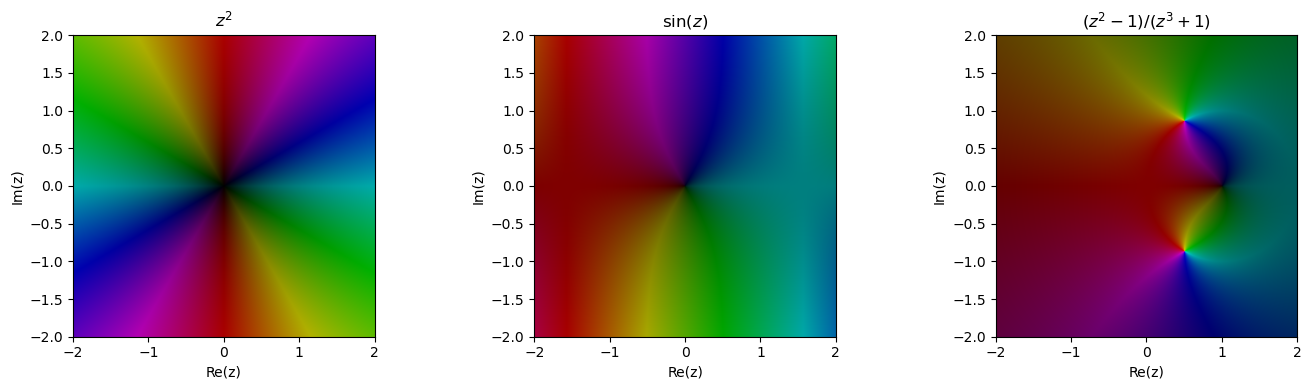

In [3]:
def domain_color(f, re_range=(-2, 2), im_range=(-2, 2), n=500):
    """Domain coloring visualization of a complex function f."""
    x = np.linspace(*re_range, n)
    y = np.linspace(*im_range, n)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    W = f(Z)
    
    hue        = (np.angle(W) + np.pi) / (2 * np.pi)   # [0, 1]
    brightness = 1 - 1 / (1 + np.abs(W)**0.5)          # [0, 1)
    saturation = np.ones_like(hue)
    
    hsv = np.stack([hue, saturation, brightness], axis=-1)
    rgb = hsv_to_rgb(hsv)
    
    return X, Y, rgb


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fns = [
    (lambda z: z**2,         r'$z^2$'),
    (lambda z: np.sin(z),    r'$\sin(z)$'),
    (lambda z: (z**2 - 1) / (z**3 + 1),  r'$(z^2-1)/(z^3+1)$'),
]
for ax, (f, title) in zip(axes, fns):
    X, Y, rgb = domain_color(f)
    
    ax.imshow(rgb, origin='lower', extent=[-2, 2, -2, 2])
    ax.set_title(title)
    ax.set_xlabel('Re(z)')
    ax.set_ylabel('Im(z)')

plt.tight_layout()
plt.show()

---

## Problem 1: Complex Roots

Find and plot all n-th roots of unity: $z^n = 1 \Rightarrow z_k = e^{2\pi i k/n}$.

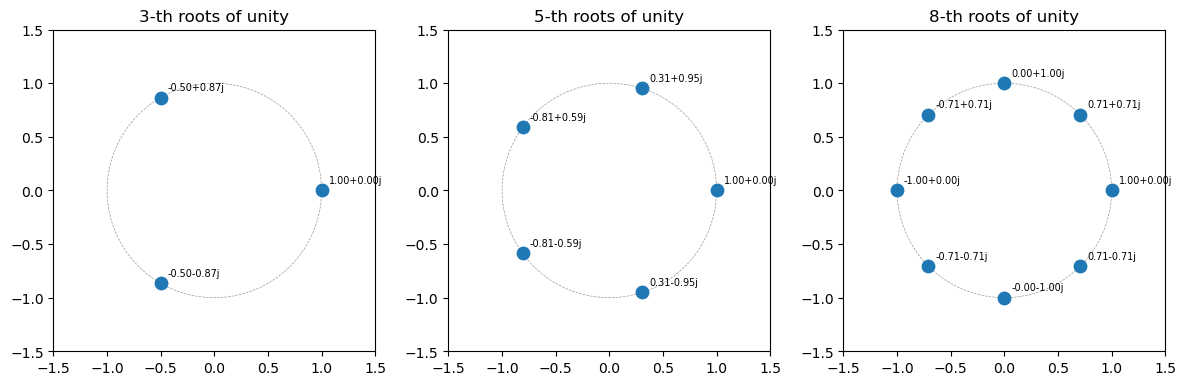

In [4]:
def prob1(ns=(3, 5, 8)):
    """Plot n-th roots of unity for several n."""
    fig, axes = plt.subplots(1, len(ns), figsize=(4*len(ns), 4))
    theta = np.linspace(0, 2*np.pi, 400)
    
    for ax, n in zip(axes, ns):
        roots = np.exp(2j * np.pi * np.arange(n) / n)
        ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.5, alpha=0.4)
        ax.scatter(roots.real, roots.imag, s=80, zorder=5)
        for r in roots:
            ax.annotate(f'{r:.2f}', (r.real, r.imag), textcoords='offset points',
                        xytext=(5, 5), fontsize=7)
        ax.set_aspect('equal')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_title(f'{n}-th roots of unity')
    
    plt.tight_layout()
    plt.show()
    

prob1()

## Problem 2: Complex Derivative (Numerical)

A function f is **analytic** (holomorphic) if $f'(z) = \lim_{h\to0} [f(z+h)-f(z)]/h$ exists independently of direction in ℂ.

Compute the complex derivative numerically and verify it matches the analytic formula.

In [5]:
def complex_derivative(f, z, h=1e-7):
    """Numerical complex derivative via centered finite difference."""
    return (f(z + h) - f(z - h)) / (2 * h)


def prob2():
    """Verify complex derivatives for several functions."""
    z0 = 1 + 2j
    tests = [
        (lambda z: z**3,          lambda z: 3*z**2,           'z³'),
        (lambda z: np.exp(z),     lambda z: np.exp(z),        'eˢ'),
        (lambda z: np.sin(z),     lambda z: np.cos(z),        'sin(z)'),
        (lambda z: 1/z,           lambda z: -1/z**2,          '1/z'),
        (lambda z: z**2 * np.exp(z), lambda z: z*(z+2)*np.exp(z), 'z²eˢ'),
    ]
    print(f"{'Function':<10} {'Numerical':>22} {'Analytic':>22} {'Error':>12}")
    for f, df, name in tests:
        num = complex_derivative(f, z0)
        exact = df(z0)
        err = abs(num - exact)
        print(f"{name:<10} {str(num):>22} {str(exact):>22} {err:12.2e}")
        

prob2()

Function                Numerical               Analytic        Error
z³         (-8.999999998593466+12.000000002565514j)               (-9+12j)     2.93e-09
eˢ         (-1.1312043834976748+2.471726672226282j) (-1.1312043837568135+2.4717266720048188j)     3.41e-10
sin(z)     (2.0327230054739687-3.051897800032677j) (2.0327230070196656-3.0518977991518j)     1.78e-09
1/z        (0.1199999999368373+0.16000000019333882j)           (0.12+0.16j)     2.03e-10
z²eˢ       (-18.64260899431258-11.521361731325896j) (-18.642608992281737-11.521361742059327j)     1.09e-08


## Problem 3: Contour Plots of Real and Imaginary Parts

For an analytic function f(z) = u(x,y) + iv(x,y), the level curves of u and v are **orthogonal** (Cauchy-Riemann equations). Visualize this.

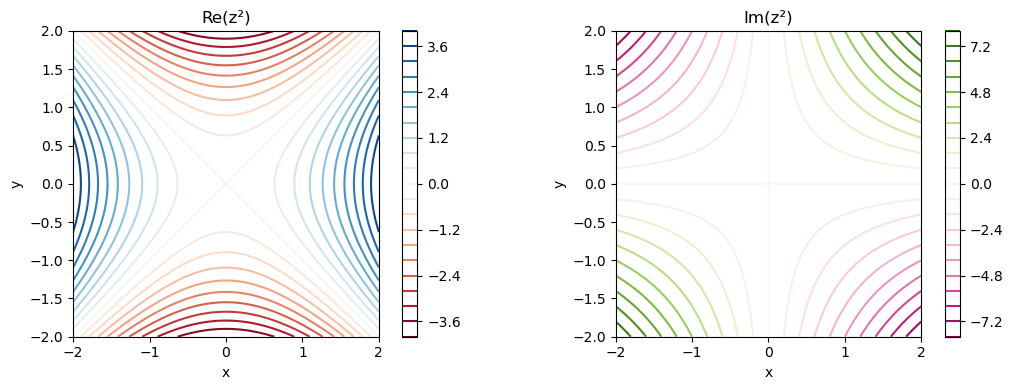

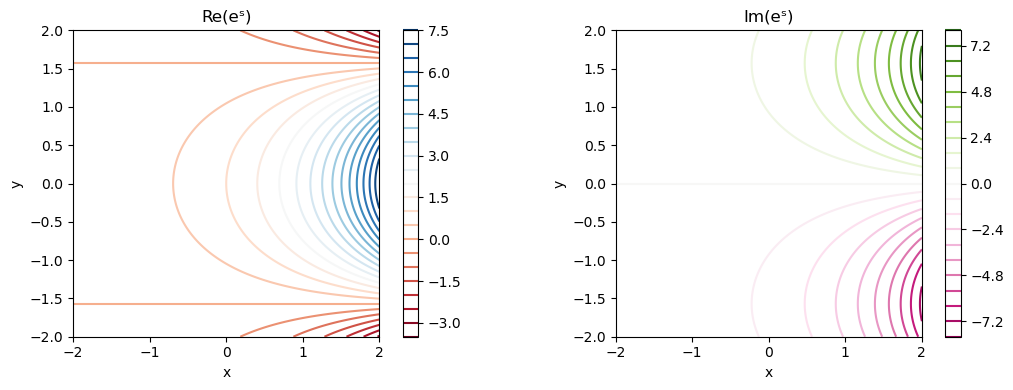

In [6]:
def prob3(f=lambda z: z**2, title='f(z) = z²'):
    """Plot Re(f) and Im(f) contours; verify orthogonality visually."""
    x = np.linspace(-2, 2, 400)
    y = np.linspace(-2, 2, 400)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    W = f(Z)
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    c1 = axes[0].contour(X, Y, W.real, levels=20, cmap='RdBu')
    axes[0].set_title(f'Re({title})')
    plt.colorbar(c1, ax=axes[0])
    
    c2 = axes[1].contour(X, Y, W.imag, levels=20, cmap='PiYG')
    axes[1].set_title(f'Im({title})')
    plt.colorbar(c2, ax=axes[1])
    
    for ax in axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()


prob3(lambda z: z**2, 'z²')
prob3(lambda z: np.exp(z), 'eˢ')

## Problem 4: Zeros and Poles via Domain Coloring

In domain coloring, **zeros** appear where all colors meet at a dark center; **poles** appear where all colors meet at a bright (white) center. Count them from the plot.

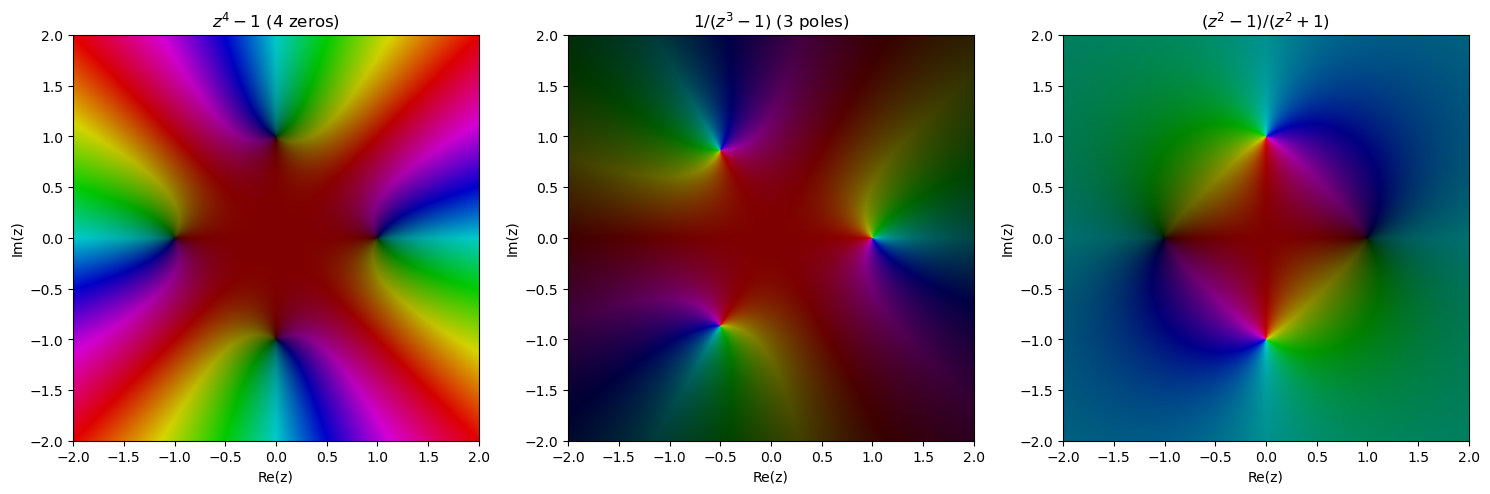

In [7]:
def prob4():
    """Domain color plots; identify zeros and poles."""
    fns = [
        (lambda z: z**4 - 1,                    r'$z^4 - 1$ (4 zeros)'),
        (lambda z: 1 / (z**3 - 1),             r'$1/(z^3-1)$ (3 poles)'),
        (lambda z: (z**2 - 1)/(z**2 + 1),      r'$(z^2-1)/(z^2+1)$'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (f, title) in zip(axes, fns):
        X, Y, rgb = domain_color(f, re_range=(-2, 2), im_range=(-2, 2))
        ax.imshow(rgb, origin='lower', extent=[-2, 2, -2, 2])
        ax.set_title(title)
        ax.set_xlabel('Re(z)')
        ax.set_ylabel('Im(z)')
    plt.tight_layout()
    
    plt.show()

prob4()

## Problem 5: Analytic vs Non-Analytic Functions

Verify the Cauchy-Riemann equations numerically: for f = u + iv,
$$\frac{\partial u}{\partial x} = \frac{\partial v}{\partial y}, \qquad \frac{\partial u}{\partial y} = -\frac{\partial v}{\partial x}$$

In [8]:
def cauchy_riemann_check(f, z0, h=1e-6):
    """Numerically check the Cauchy-Riemann equations at z0."""
    def u(x, y): return f(x + 1j*y).real
    def v(x, y): return f(x + 1j*y).imag
    
    x0, y0 = z0.real, z0.imag
    ux = (u(x0+h, y0) - u(x0-h, y0)) / (2*h)
    uy = (u(x0, y0+h) - u(x0, y0-h)) / (2*h)
    vx = (v(x0+h, y0) - v(x0-h, y0)) / (2*h)
    vy = (v(x0, y0+h) - v(x0, y0-h)) / (2*h)
    
    cr1 = abs(ux - vy)  # should be 0
    cr2 = abs(uy + vx)  # should be 0
    return cr1, cr2


z0 = 1.5 + 0.7j
print("Analytic functions (CR residuals should be ~0):")
for f, name in [(lambda z: z**2, 'z²'), (np.exp, 'exp(z)'), (np.sin, 'sin(z)')]:
    cr1, cr2 = cauchy_riemann_check(f, z0)
    print(f"  {name}: CR1={cr1:.2e}, CR2={cr2:.2e}")

print("\nNon-analytic functions (CR residuals should be non-zero):")
for f, name in [(np.conj, 'conj(z)'), (np.abs, '|z|')]:
    try:
        cr1, cr2 = cauchy_riemann_check(f, z0)
        print(f"  {name}: CR1={cr1:.2e}, CR2={cr2:.2e}")
        
    except Exception as e:
        print(f"  {name}: {e}")

Analytic functions (CR residuals should be ~0):
  z²: CR1=4.44e-10, CR2=3.33e-10
  exp(z): CR1=4.44e-10, CR2=2.22e-10
  sin(z): CR1=1.08e-10, CR2=2.43e-11

Non-analytic functions (CR residuals should be non-zero):
  conj(z): CR1=2.00e+00, CR2=0.00e+00
  |z|: CR1=9.06e-01, CR2=4.23e-01
